# Linear Regression: Predict Cell Site Traffic
Business Problem

A network planner wants to predict hourly traffic (GB) at a cell site.

## Step 1 – Generate Dataset

In [2]:
# Generate Telco Traffic Dataset

import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

active_users = np.random.randint(100, 1000, n)
video_users = np.random.randint(10, 500, n)

traffic_gb = (
    active_users * 0.05 +
    video_users * 0.15 +
    np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    'active_users': active_users,
    'video_users': video_users,
    'traffic_gb': traffic_gb
})

df.head()

,active_users,video_users,traffic_gb
0,202,465,75.807532
1,535,471,94.891215
2,960,224,86.177011
3,370,261,59.293756
4,206,199,37.501199


## Step 2 – Visualize Data

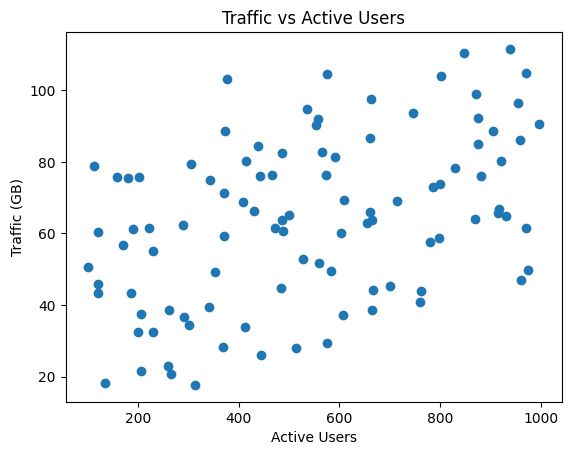

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['active_users'], df['traffic_gb'])

plt.xlabel('Active Users')
plt.ylabel('Traffic (GB)')
plt.title('Traffic vs Active Users')

plt.show()

## Step 3 – Build Model

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['active_users', 'video_users']]
y = df['traffic_gb']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Step 4 – Predict

In [5]:
predictions = model.predict(X_test)

print(predictions[:10])

[42.49002902 57.79978368 83.27479269 65.78131265 75.41919693 83.39871092
 54.74790318 61.60640801 84.77853525 80.4906514 ]


## Step 5 – Evaluate

In [6]:
print("R² Score:", model.score(X_test, y_test))

R² Score: 0.9565874421165238


## Step 6 – Actual vs Predicted

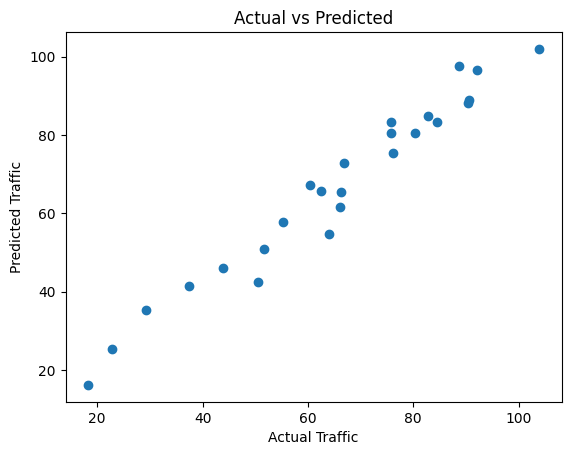

In [7]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Actual vs Predicted")

plt.show()

## Add Regression Line Plot

Because we have multiple inputs (active_users, video_users), a simple 2D regression line is easier if we use only active_users.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


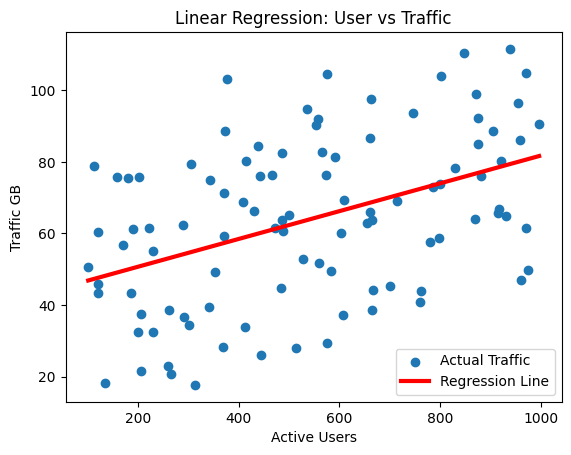

In [8]:
# ==========================================
# Plot Regression Line
# ==========================================

from sklearn.linear_model import LinearRegression

# Use only active_users for visualization
X_plot = df[['active_users']]
y_plot = df['traffic_gb']


# Train simple model
lr_plot = LinearRegression()

lr_plot.fit(X_plot, y_plot)


# Create line points
x_line = np.linspace(
    X_plot.min(),
    X_plot.max(),
    100
).reshape(-1,1)


y_line = lr_plot.predict(x_line)


# Plot data
plt.scatter(
    X_plot,
    y_plot,
    label="Actual Traffic"
)


# Plot regression line
plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=3,
    label="Regression Line"
)


plt.xlabel("Active Users")
plt.ylabel("Traffic GB")

plt.title(
    "Linear Regression: User vs Traffic"
)

plt.legend()

plt.show()

       *
     *
   *
 *
-----------------
     /
    /
   /
 Red line = predicted traffic

Meaning:

As active users increase, traffic increases